# **Artificial Neural Network and Deep Learning HOMEWORK_1 code**
## Group: Gradient Ascent
Team members:
Edoardo Fortuna(233817),
Alberto Cantele(259056),
Massimo Bruscaglioni(251705)


---

## 🌐Connect Colab to Google Drive:

In [2]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/My Drive/GradientAscent_TrainingSet

Mounted at /gdrive
/gdrive/My Drive/GradientAscent_TrainingSet


## ⚙️ Import Libraries

In [3]:
import hashlib
import random
from keras.src.regularizers import regularizers
from keras.src.utils.module_utils import torchvision
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.utils import compute_class_weight
from tensorflow.keras import layers as tfkl
from tensorflow.python.keras.callbacks import EarlyStopping
from tensorflow import keras as tfk
from sklearn.metrics import f1_score
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Set seed for reproducibility
seed = 42

## ⏳ Load Data

In [4]:
#Load data from the file called training_set using numPy function load

data = np.load("training_set.npz")

#Assign each column of the file to a variable, thus to create a variable for features (X) and a variable for targets (y)

X = data['images']
y = data['labels']

## 🕺 Pre processing

In [5]:
#Define all function used for the preprocessing: duplicate removing and image hashing

def hash_image(image):
    return hashlib.sha256(image.tobytes()).hexdigest()

def remove_duplicates(images, labels):
    unique_hashes = set()
    unique_images = []
    unique_labels = []

    for image, label in zip(images, labels):
        image_hash = hash_image(image)
        if image_hash not in unique_hashes:
            unique_hashes.add(image_hash)
            unique_images.append(image)
            unique_labels.append(label)

    return np.array(unique_images), np.array(unique_labels)

#Remove duplicates and using the previous declared functions and from the unique images array remove outliers overwriting all the array excluding last two images
#Last two images were selected after an inspection

unique_images, unique_labels = remove_duplicates(X, y)
unique_images = unique_images[:len(unique_images) - 2]
unique_labels = unique_labels[:len(unique_labels) - 2]

## 🪠Splitting data and class weights computation

In [6]:
# Split unique images and unique labels arrays in train validation and test sets using a 70-15-15 convention (70% for training, 15% for validation and test)

X_train, X_val_test, y_train, y_val_test = train_test_split(unique_images, unique_labels, test_size=0.3,
                                                            random_state=42, stratify=unique_labels)

X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5,
                                                            random_state=42, stratify=y_val_test)

#Compute the class classification weights

c_weights = np.zeros(8)
count = np.zeros(8)

for i in range(8):
    count[i] = np.count_nonzero(y_train == i)
weights=compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(y_train),
    y = y_train.ravel()
)

class_weight_dict = dict(enumerate(weights))

## 🪩Augmentation

### Set up Augmentation parameters

In [8]:
#Before apply augmentation, set up all the necessary parameters

# augMix standard input parameters
input_images_train = X_train
input_probability = 0.7                 # chance of augmenting an image
input_width = 3                         # Number of augmentations on each mix
input_depth = 3                         # Number of mixes for each combination
input_alpha = 0.5                       # Importance of distorced images on the mix
input_beta = 0.5                        # Importance of original image on the mix
# Input parameters for get_border_color function
border=100
vertical_border_amplifier=np.ones((border,X_train.shape[1],3))
orizzontal_border_amplifier=np.ones((X_train.shape[1]+2*border,border,3))

# set up base transformations' parameters
base_transforms = [
        T.ColorJitter(brightness=0.2, contrast=0.4, saturation=0.2, hue=0.5),
        T.RandomSolarize(160),
        T.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
        T.RandomAutocontrast(p=0.5),
        T.RandomEqualize(p=0.5),
        T.RandomHorizontalFlip(),
        T.RandomVerticalFlip(),
        T.RandomRotation(30),
        T.RandomAffine(degrees=15,shear=30, fill=(210,170,180),scale=(0.8,1.2)),
        T.RandomPerspective(distortion_scale=0.1, p=0.5)
    ]

# Input parameters fot apply_random_transofrms
num_ops = input_width

# Rescaling factor
Rescaling_factor = 255.0

### Define augmentation functions

In [9]:
# create an AugMix personalized pipeline
def get_augmix_pipeline(probability, width, depth, alpha, beta):
    return torchvision.transforms.AugMix(
        p=probability,
        width=width,
        depth=depth,
        alpha=alpha,
        beta=beta
    )

# Get the image with expanded borders
# Borders are expanded in order to reduce the visual artifacts of transformationed image borders on the mixed images

def get_border_color(img):
    left = np.mean(img[0:5,:],axis=(0,1)).astype(np.uint8)
    right = np.mean(img[-5:,:],axis=(0,1)).astype(np.uint8)
    top = np.mean(img[:,0:5],axis=(0,1)).astype(np.uint8)
    bottom = np.mean(img[:,-5:],axis=(0,1)).astype(np.uint8)
    img=np.concatenate((vertical_border_amplifier*top,img,vertical_border_amplifier*bottom),axis=0)
    img=np.concatenate((orizzontal_border_amplifier*left,img,orizzontal_border_amplifier*right),axis=1)

    return img

# apply augmentation pipeline usigng AugMix
def apply_augmentation_with_augmix(images, probability, width, depth, alpha, beta):
    augmented_images = []
    for img in images:
        imgv2 = get_border_color(img)
        imgv2 = np.clip(imgv2, 0, 255).astype(np.uint8)

        if random.random() < probability:                   # Apply AugMix with probability
            augmented_image = augmix(imgv2, width, depth, alpha, beta)
            augmented_image = augmented_image[border:(len(imgv2[0])-border),border:(len(imgv2[1])-border)]
            augmented_images.append(augmented_image)
        else:
            imgv2 = imgv2[border:(len(imgv2[0])-border),border:(len(imgv2[1])-border)]
            augmented_images.append(imgv2)                  # if AugMix is not applied image remain unaltered
    return np.array(augmented_images)

#Apply random transofrmations
def apply_random_transforms(img, num_ops):

    ops = random.sample(base_transforms, num_ops)
    for op in ops:
        img = op(img)
    return np.array(img)


def augmix(image,width, depth, alpha, beta):
    pil_image = Image.fromarray(image)
    mixed_images = []
    for _ in range(depth):
        image_copy = pil_image.copy()
        mixed_image = apply_random_transforms(image_copy, width)
        mixed_images.append(np.array(mixed_image))

    mixed_image = np.zeros_like(np.array(pil_image), dtype=np.float32)
    for img in mixed_images:
        mixed_image += img / depth

    mixed_image = mixed_image * alpha + np.array(pil_image) * beta
    mixed_image = np.clip(mixed_image, 0, 255).astype(np.uint8)

    return mixed_image

X_train=apply_augmentation_with_augmix(input_images_train,input_probability,input_width,input_depth,input_alpha,input_beta)

X_train=X_train/Rescaling_factor
X_test=X_test/Rescaling_factor

## 🏋️‍♂️Training

### Define training parameters

In [13]:
#define model input parameters
input_filters = 16
input_kernel_size = 3
input_dense_units = 64
input_dropout_rate = 0.5
input_batch_size = 32
input_pool_size = 2
inputs = (X_train.shape[1], X_train.shape[2], X_train.shape[3])

#Define L2 regularizer
l2_reg = 0.005

#training parameter
eps = 100 #define epochs
pat = 5 #define early stop patience

### define Model

In [16]:
def build_model(filters, kernel_size, dense_units, dropout_rate, pool_size, l2):
    model = tfk.Sequential()
    model.add(tfkl.Conv2D(filters, kernel_size, activation='relu', input_shape=inputs, kernel_regularizer=regularizers.L2(l2)))
    model.add(tfkl.BatchNormalization())
    model.add(tfkl.MaxPooling2D((pool_size, pool_size)))

    model.add(tfkl.Conv2D(filters * 2, kernel_size, activation='relu', kernel_regularizer=regularizers.L2(l2)))
    model.add(tfkl.BatchNormalization())
    model.add(tfkl.MaxPooling2D((pool_size, pool_size)))

    model.add(tfkl.Conv2D(filters * 4, kernel_size, activation='relu', kernel_regularizer=regularizers.L2(l2)))
    model.add(tfkl.BatchNormalization())
    model.add(tfkl.MaxPooling2D((pool_size, pool_size)))

    model.add(tfkl.Flatten())

    model.add(tfkl.Dense(dense_units, activation='relu', kernel_regularizer=regularizers.L2(l2)))
    model.add(tfkl.Dropout(dropout_rate))

    model.add(tfkl.Dense(8, activation='softmax', kernel_regularizer=regularizers.L2(l2)))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

### Train the model

In [17]:
#Call early stopping function to prevent overfitting
early_stopping = EarlyStopping(monitor='val_accuracy', patience=pat, restore_best_weights=True)

#call build model function to initialize the NN
model = build_model(input_filters,input_kernel_size, input_dense_units,input_dropout_rate, input_pool_size, l2_reg)

#Fit the model
history = model.fit(X_train,y_train, validation_data=(X_test,y_test), epochs=eps,callbacks=[early_stopping], class_weight=class_weight_dict)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 109s 404ms/step - accuracy: 0.2711 - loss: 2.9354 - val_accuracy: 0.1372 - val_loss: 8.4983
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 94s 358ms/step - accuracy: 0.4607 - loss: 2.0891 - val_accuracy: 0.5510 - val_loss: 1.5715
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 140s 352ms/step - accuracy: 0.6135 - loss: 1.5198 - val_accuracy: 0.6375 - val_loss: 1.3792
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 138s 335ms/step - accuracy: 0.6682 - loss: 1.3284 - val_accuracy: 0.4361 - val_loss: 2.6884
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 89s 339ms/step - accuracy: 0.7260 - loss: 1.1826 - val_accuracy: 0.7250 - val_loss: 1.1773
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 141s 338ms/step - accuracy: 0.7698 - loss: 1.0799 - val_accuracy: 0.7122 - val_loss: 1.1782
Epoch 7/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 142s 338ms/step - accuracy: 0.7928 - loss: 0.9869 - val_accuracy: 0.8483 - val_loss: 0.8274
Epoch 8/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 143s 342ms/step - accuracy: 0.

## 🥁Prediction

57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step
Test accuracy: 0.8773006134969326
F1 score: 0.8793283426748575


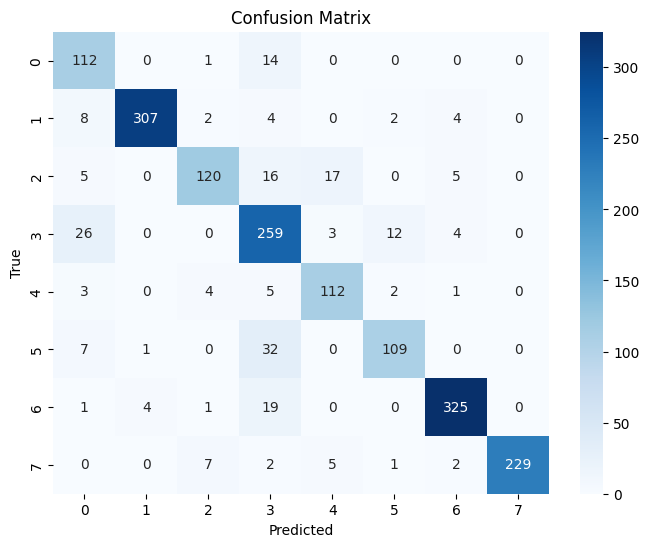

In [21]:
#Predict the model using the previus splitted portion of the dataset aimed to evalueate the model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes, average='weighted')
cm = confusion_matrix(y_test, y_pred_classes)

#Print the results
print('Test accuracy:', accuracy)
print('F1 score:',f1)

#Print the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()